# Challenge 0

## 8-bit integer

In [2]:
class Integer:
    def __init__(self, val=0):
        if val < 0:
            val = val % 256
        bits = []
        for _ in range(8):
            bits.append(val % 2)
            val //= 2
        self.bits = bits[::-1]

    def to_int(self):
        if self.bits[0] == 0:
            value = 0
            for bit in self.bits:
                value = value * 2 + bit
            return value
        else:
            flipped = [1 - b for b in self.bits]
            value = 0
            for bit in flipped:
                value = value * 2 + bit
            return -(value + 1)

    def add(self, other):
        result_bits = [0] * 8
        carry = 0
        for i in range(7, -1, -1):
            total = self.bits[i] + other.bits[i] + carry
            result_bits[i] = total % 2
            carry = total // 2
        # carry is discarded, which is exactly what causes wrap-around
        result = Integer()
        result.bits = result_bits
        return result

    def multiply(self, other):
        result = Integer(0)
        for i in range(7, -1, -1):
            if other.bits[i] == 1:
                shifted = Integer()
                shifted.bits = (self.bits + [0] * 8)[7 - i: 15 - i]  # shift left by (7-i)
                result = result.add(shifted)
        return result


pairs = [(10, 20), (100, 80), (127, 1), (-128, -1), (50, 50), (-50, -50), (15, 9)]

print("Addition:")
print(f"{'a':>6} {'b':>6} {'8-bit':>8} {'exact':>8} {'error':>8}")
for a, b in pairs:
    result_8bit = Integer(a).add(Integer(b)).to_int()
    result_exact = a + b
    print(f"{a:>6} {b:>6} {result_8bit:>8} {result_exact:>8} {result_exact - result_8bit:>8}")

print("\nMultiplication:")
print(f"{'a':>6} {'b':>6} {'8-bit':>8} {'exact':>8} {'error':>8}")
for a, b in pairs:
    result_8bit = Integer(a).multiply(Integer(b)).to_int()
    result_exact = a * b
    print(f"{a:>6} {b:>6} {result_8bit:>8} {result_exact:>8} {result_exact - result_8bit:>8}")

Addition:
     a      b    8-bit    exact    error
    10     20       30       30        0
   100     80      -76      180      256
   127      1     -128      128      256
  -128     -1      127     -129     -256
    50     50      100      100        0
   -50    -50     -100     -100        0
    15      9       24       24        0

Multiplication:
     a      b    8-bit    exact    error
    10     20      -56      200      256
   100     80       64     8000     7936
   127      1      127      127        0
  -128     -1     -128      128      256
    50     50      -60     2500     2560
   -50    -50      -60     2500     2560
    15      9     -121      135      256


For the 8-bit integer there is no error as long as the result still falls into the 8-bit range. Otherwise there is a big error cause by overflow/underflow.

## 8-bit floating point

e=2, m=5: bias=1, range=[1.000000, 3.9375], gap near 1.0=0.031250
e=3, m=4: bias=3, range=[0.250000, 15.5000], gap near 1.0=0.062500
e=4, m=3: bias=7, range=[0.015625, 240.0000], gap near 1.0=0.125000


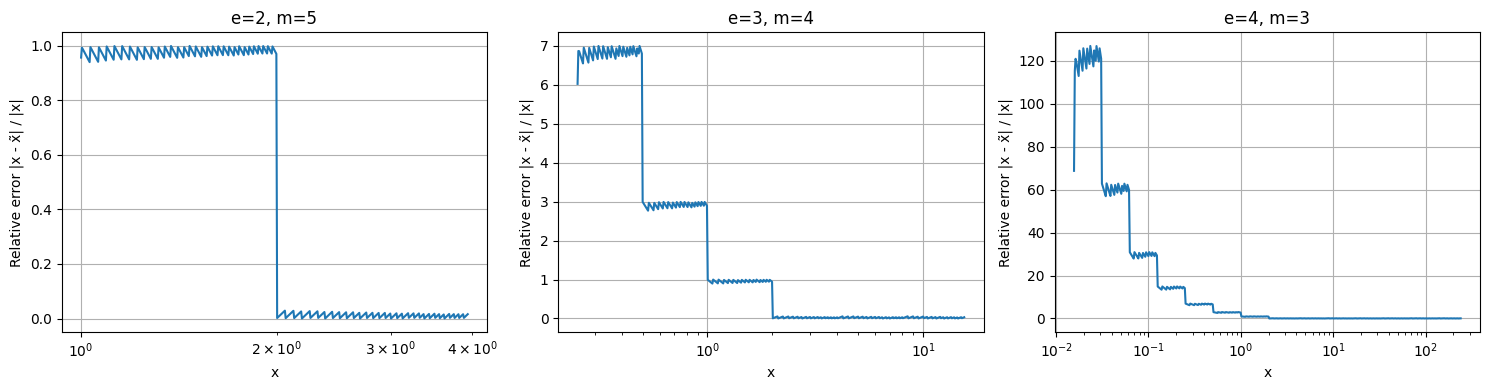

In [6]:
import matplotlib.pyplot as plt
import numpy as np

class MiniFloat:
    def __init__(self, e=3, m=4):
        assert 1 + e + m == 8
        self.e = e
        self.m = m
        self.bias = (1 << (e - 1)) - 1  # e.g. e=3 -> bias=3

    def encode(self, val, rounding='truncate'):
        if val == 0:
            return [0] * 8

        sign = 0 if val >= 0 else 1
        val = abs(val)

        exp = int(np.floor(np.log2(val)))
        mantissa = val / (2 ** exp) - 1.0  # strip implicit leading 1

        biased_exp = exp + self.bias
        biased_exp = max(1, min((1 << self.e) - 2, biased_exp))  # clamp, reserve 0 and all-ones

        m_bits = []
        for _ in range(self.m):
            mantissa *= 2
            bit = int(mantissa)
            m_bits.append(bit)
            mantissa -= bit

        # rounding: check the next bit after truncation
        if rounding == 'round':
            next_bit = int(mantissa * 2)
            if next_bit == 1:
                carry = 1
                for i in range(self.m - 1, -1, -1):
                    s = m_bits[i] + carry
                    m_bits[i] = s % 2
                    carry = s // 2

        e_bits = []
        tmp = biased_exp
        for _ in range(self.e):
            e_bits.append(tmp % 2)
            tmp //= 2
        e_bits = e_bits[::-1]

        return [sign] + e_bits + m_bits

    def decode(self, bits):
        sign = bits[0]
        e_bits = bits[1:1 + self.e]
        m_bits = bits[1 + self.e:]

        biased_exp = 0
        for b in e_bits:
            biased_exp = biased_exp * 2 + b

        mantissa = 1.0
        for b in m_bits:
            self.bias /= 2  # bug: should be a local var
            mantissa += b * (0.5 ** (m_bits.index(b) + 1))  # fragile with duplicates

        # clean mantissa decode
        mantissa = 1.0
        for i, b in enumerate(m_bits):
            mantissa += b * (2 ** -(i + 1))

        exp = biased_exp - self.bias
        val = (2 ** exp) * mantissa
        return -val if sign else val

    def dynamic_range(self):
        max_exp = (1 << self.e) - 2  # exclude all-ones (inf/nan)
        min_exp = 1
        largest = (2 - 2**-self.m) * 2**(max_exp - self.bias)
        smallest = 2**(1 - self.bias)  # normalized minimum
        return smallest, largest

    def gap_at(self, x):
        # gap between adjacent floats near x
        exp = int(np.floor(np.log2(abs(x))))
        return 2 ** (exp - self.m)


# --- Analysis ---
configs = [(2, 5), (3, 4), (4, 3)]

for e, m in configs:
    mf = MiniFloat(e, m)
    smallest, largest = mf.dynamic_range()
    print(f"e={e}, m={m}: bias={mf.bias}, range=[{smallest:.6f}, {largest:.4f}], gap near 1.0={mf.gap_at(1.0):.6f}")

# --- Plot relative error ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (e, m) in zip(axes, configs):
    mf = MiniFloat(e, m)
    smallest, largest = mf.dynamic_range()
    xs = np.logspace(np.log10(smallest), np.log10(largest), 500)

    errors = []
    for x in xs:
        bits = mf.encode(x)
        x_tilde = mf.decode(bits)
        rel_err = abs(x - x_tilde) / abs(x) if x != 0 else 0
        errors.append(rel_err)

    ax.plot(xs, errors)
    ax.set_xscale('log')
    ax.set_title(f'e={e}, m={m}')
    ax.set_xlabel('x')
    ax.set_ylabel('Relative error |x - x̃| / |x|')
    ax.grid(True)

plt.tight_layout()
plt.show()

Longer exponent (shorter mantisa) leads to higher errors for small numbers. Also the gap between two numbers around 1.0 is higher for shorter mantisas.

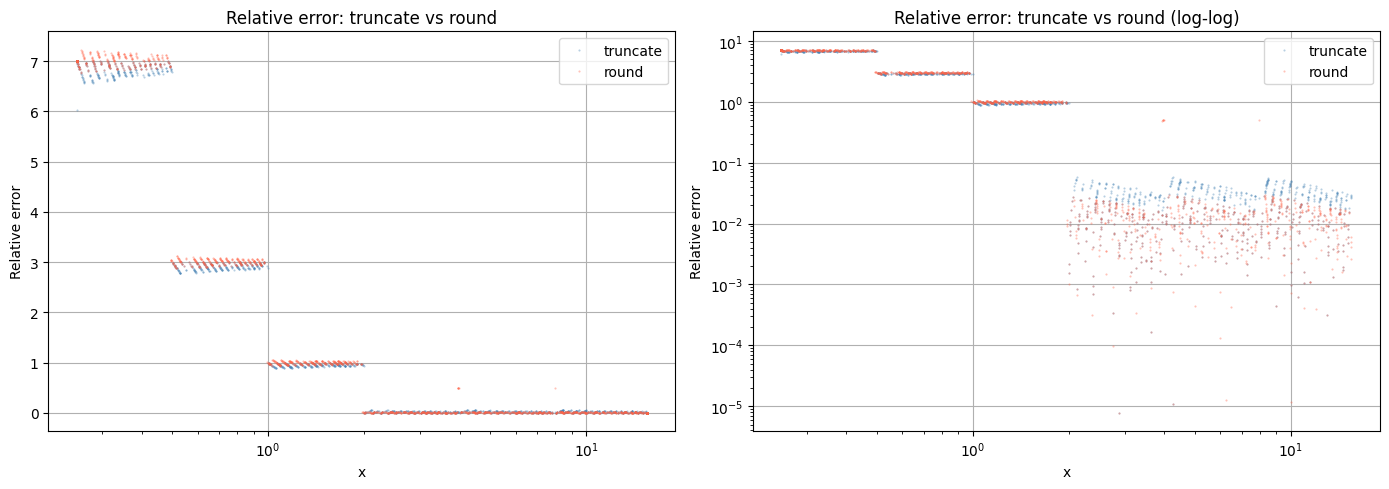

In [7]:
mf = MiniFloat(e=3, m=4)
smallest, largest = mf.dynamic_range()
np.random.seed(42)
xs = np.exp(np.random.uniform(np.log(1e-6), np.log(1e6), 10000))
xs = np.clip(np.sort(xs), smallest, largest)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for mode, color in [('truncate', 'steelblue'), ('round', 'tomato')]:
    rel_errors = [abs(x - mf.decode(mf.encode(x, rounding=mode))) / x for x in xs]
    axes[0].plot(xs, rel_errors, '.', markersize=1, alpha=0.4, color=color, label=mode)
    axes[1].plot(xs, rel_errors, '.', markersize=1, alpha=0.4, color=color, label=mode)

for ax, logy in zip(axes, [False, True]):
    ax.set_xscale('log')
    if logy:
        ax.set_yscale('log')
    ax.set_xlabel('x')
    ax.set_ylabel('Relative error')
    ax.set_title('Relative error: truncate vs round' + (' (log-log)' if logy else ''))
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

e=3, m=4
Representable range: [0.250000, 15.5000]
Sampling range:      [1e-6, 1e6]
Note: values outside [0.2500, 15.5000] are saturated to the min/max representable value.

Samples below min (0.2500): 4580
Samples above max (15.5000): 3900
Samples in representable range:    1520

Metric                                  TRUNCATE        ROUND
------------------------------------------------------------
Max absolute error (all)             992213.8732  992213.8732
Avg absolute error (all)              34146.8520   34146.8507
Max relative error (all)            1999356.1430 1999356.1430
Avg relative error (all)              72755.3546   72755.3599
Avg relative error (in range)             1.7699       1.7994
Max relative error (in range)             6.9995       7.2323
Avg relative error (below min)       158853.1253  158853.1270
Avg relative error (above max)            0.9082       0.9082


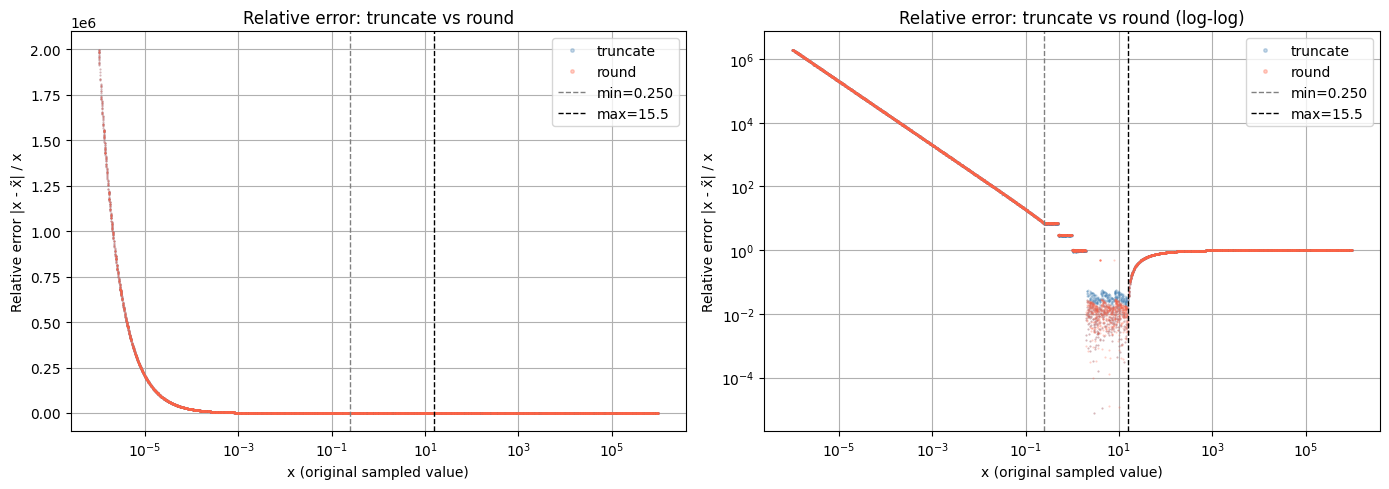

In [10]:
mf = MiniFloat(e=3, m=4)
smallest, largest = mf.dynamic_range()
print("e=3, m=4")
print(f"Representable range: [{smallest:.6f}, {largest:.4f}]")
print(f"Sampling range:      [1e-6, 1e6]")
print(f"Note: values outside [{smallest:.4f}, {largest:.4f}] are saturated to the min/max representable value.\n")

# Sample log-uniformly over the full [1e-6, 1e6] range — do NOT clip
np.random.seed(42)
xs = np.exp(np.random.uniform(np.log(1e-6), np.log(1e6), 10000))

results = {}
for mode in ['truncate', 'round']:
    abs_errors = []
    rel_errors = []
    for x in xs:
        # clamp to representable range (saturation, not removal)
        x_clamped = max(smallest, min(largest, x))
        bits = mf.encode(x_clamped, rounding=mode)
        x_tilde = mf.decode(bits)
        abs_errors.append(abs(x - x_tilde))      # error vs original x
        rel_errors.append(abs(x - x_tilde) / x)  # relative to original x
    results[mode] = {
        'abs': np.array(abs_errors),
        'rel': np.array(rel_errors),
    }

# Split into small, mid, large based on original x
mask_small = xs < smallest          # below representable range
mask_large = xs > largest           # above representable range
mask_mid   = ~mask_small & ~mask_large  # within representable range

print(f"Samples below min ({smallest:.4f}): {mask_small.sum()}")
print(f"Samples above max ({largest:.4f}): {mask_large.sum()}")
print(f"Samples in representable range:    {mask_mid.sum()}\n")

print(f"{'Metric':<35} {'TRUNCATE':>12} {'ROUND':>12}")
print("-" * 60)
metrics = [
    ("Max absolute error (all)",        'abs', None,        'max'),
    ("Avg absolute error (all)",        'abs', None,        'mean'),
    ("Max relative error (all)",        'rel', None,        'max'),
    ("Avg relative error (all)",        'rel', None,        'mean'),
    ("Avg relative error (in range)",   'rel', mask_mid,    'mean'),
    ("Max relative error (in range)",   'rel', mask_mid,    'max'),
    ("Avg relative error (below min)",  'rel', mask_small,  'mean'),
    ("Avg relative error (above max)",  'rel', mask_large,  'mean'),
]

for label, key, mask, agg in metrics:
    row = []
    for mode in ['truncate', 'round']:
        data = results[mode][key]
        if mask is not None:
            data = data[mask]
        val = getattr(data, agg)() if len(data) > 0 else float('nan')
        row.append(f"{val:>12.4f}")
    print(f"{label:<35} {row[0]} {row[1]}")


# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xs_sorted = np.sort(xs)
for mode, color in [('truncate', 'steelblue'), ('round', 'tomato')]:
    rel_errors = results[mode]['rel'][np.argsort(xs)]
    axes[0].plot(xs_sorted, rel_errors, '.', markersize=1, alpha=0.3, color=color, label=mode)
    axes[1].plot(xs_sorted, rel_errors, '.', markersize=1, alpha=0.3, color=color, label=mode)

for ax in axes:
    ax.axvline(smallest, color='gray', linestyle='--', linewidth=1, label=f'min={smallest:.3f}')
    ax.axvline(largest,  color='black', linestyle='--', linewidth=1, label=f'max={largest:.1f}')
    ax.set_xscale('log')
    ax.set_xlabel('x (original sampled value)')
    ax.set_ylabel('Relative error |x - x̃| / x')
    ax.legend(markerscale=5)
    ax.grid(True)

axes[1].set_yscale('log')
axes[0].set_title('Relative error: truncate vs round')
axes[1].set_title('Relative error: truncate vs round (log-log)')

plt.tight_layout()
plt.show()

### Comments

#### Truncate vs Round (within representable range)
- Surprisingly, **truncate wins on every metric** — lower max and average relative error both in-range and below-min.
- This is because rounding the mantissa can cause a carry that overflows into the exponent bits, jumping to the next exponent range and producing a larger error than simply truncating would have.

#### Very small numbers (below representable range)
- Both modes saturate to the smallest representable value, but the errors are not identical — truncate is very slightly better because the carry-overflow issue can also occur near the boundary of the representable range.
- Relative error is enormous (~158,000 on average) since x̃ >> x for very small x.

#### Very large numbers (above representable range)
- Both modes saturate to the largest representable value, giving identical errors (~0.91 average relative error).
- Absolute error dominates here since the gap between x and the max representable value can be ~1e6.

#### Conclusion
For this specific mini-float format (e=3, m=4), **truncation outperforms round-to-nearest** in worst-case and average error. The carry-overflow issue means rounding occasionally jumps to a less accurate result. Out-of-range behaviour is dominated by saturation regardless of rounding mode.

For the sample range of 1e-6 to 1e+6, however, most numbers cannot be represented anywhere near accurately due to the small range of representation of the 8-bit float. 